# K-mean clustering

first load dataset

identify which numerical feature can be used for clustering

for sampling create model with prediction with 3 clusters for that features

create scatter plot showing all 3 clusters 

use elbow method to create model with list of clusters to identify which cluster is of based used

identify cluster on basis of wcss value with lower value

recreate model with that cluster and create scatter plot with that cluster



In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans


In [2]:
df = pd.read_csv('Mall_customers.csv')

In [3]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [100]:
df.describe()

df.var(axis=0)

C:\Users\sudhi\AppData\Local\Temp/ipykernel_17732/3792582185.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.var(axis=0)


CustomerID                3350.000000
Age                        195.133166
Annual Income (k$)         689.835578
Spending Score (1-100)     666.854271
dtype: float64

In [6]:
#create model with 3 cluster

model =KMeans(n_clusters=3 , init='k-means++' , random_state= 42)

y_means =model.fit_predict(df.iloc[:,[3,4]].values)

C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [16]:
y_means

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1])

In [43]:
model.cluster_centers_[0,:]

array([87.        , 18.63157895])

In [40]:
model.cluster_centers_

array([[87.        , 18.63157895],
       [86.53846154, 82.12820513],
       [44.15447154, 49.82926829]])

In [37]:
model.cluster_centers_[:,0]

array([87.        , 86.53846154, 44.15447154])

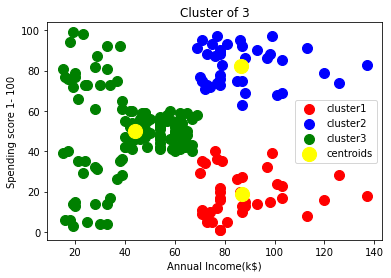

In [51]:
#check optimum value of K

X=df.iloc[:,[3,4]].values

#identify for which values cluster is near by , X[y_mean==0,0] means position where y_means ==0,0 return that value from X

plt.scatter(X[y_means==0,0], X[y_means==0,1],s=100 , c='red', label='cluster1')

plt.scatter(X[y_means==1,0], X[y_means==1,1],s=100 , c='blue', label='cluster2')


plt.scatter(X[y_means==2,0], X[y_means==2,1],s=100 , c='green', label='cluster3')

#highlight centroids in scatter plot
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='yellow' , label= 'centroids')

plt.title('Cluster of 3')

plt.xlabel('Annual Income(k$)')

plt.ylabel('Spending score 1- 100')

plt.legend()

plt.show()


In [65]:
wcss

[269981.28,
 183653.3289473684,
 106348.37306211119,
 73880.64496247195,
 44448.45544793371,
 40825.16946386946,
 33642.579220779226,
 26686.83778518778,
 24766.471609793443,
 23103.122085983916]

C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

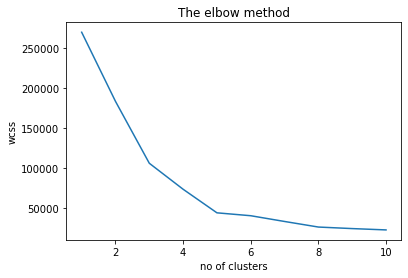

In [58]:
#choosing right cluster using model inertia

wcss=[ ]

for i in range(1,11):
    model =KMeans(n_clusters=i, init='k-means++', random_state= 42)
    model.fit(X)
    wcss.append(model.inertia_)


plt.plot(range(1,11),wcss)

plt.title('The elbow method')

plt.xlabel("no of clusters")

plt.ylabel('wcss')

plt.show()


C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


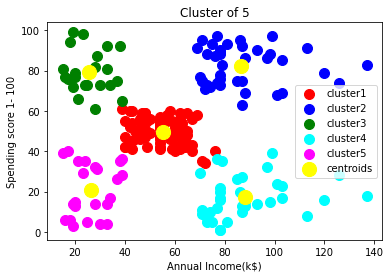

In [68]:
#create model with 5 , as graph above show cluster 5 show lowest wscc value

model =KMeans(n_clusters=5 , init='k-means++' , random_state= 42)

y_means =model.fit_predict(df.iloc[:,[3,4]].values)


#identify for which values cluster is near by , X[y_mean==0,0] means position where y_means ==0,0 return that value from X

plt.scatter(X[y_means==0,0], X[y_means==0,1],s=100 , c='red', label='cluster1')

plt.scatter(X[y_means==1,0], X[y_means==1,1],s=100 , c='blue', label='cluster2')


plt.scatter(X[y_means==2,0], X[y_means==2,1],s=100 , c='green', label='cluster3')

plt.scatter(X[y_means==3,0], X[y_means==3,1],s=100 , c='cyan', label='cluster4')

plt.scatter(X[y_means==4,0], X[y_means==4,1],s=100 , c='magenta', label='cluster5')


#highlight centroids in scatter plot
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='yellow' , label= 'centroids')

plt.title('Cluster of 5')

plt.xlabel('Annual Income(k$)')

plt.ylabel('Spending score 1- 100')

plt.legend()

plt.show()


In [36]:
X[y_means== 0,1]

array([29, 35, 11,  9, 34,  5,  7, 10,  5, 40, 12, 36, 22, 17, 20, 16,  1,
        1, 35,  5, 26, 20, 27, 13, 10, 13, 15, 14, 32, 15, 39, 24, 17, 23,
        8, 16, 28, 18], dtype=int64)

In [18]:
t= (y_means== 0,0).index

<function tuple.index(value, start=0, stop=9223372036854775807, /)>

# ## using model with 3 features to check results

In [72]:
## using model with 3 features to check results



df1 = df.copy()

In [73]:
df1.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [76]:

#convert categorical values into numeric values

df1=pd.get_dummies(df1,'gender')

In [77]:
df1.head()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100),gender_Female,gender_Male
0,1,19,15,39,0,1
1,2,21,15,81,0,1
2,3,20,16,6,1,0
3,4,23,16,77,1,0
4,5,31,17,40,1,0


In [87]:
df1.iloc[:,[2,3,4,5]]

,Annual Income (k$),Spending Score (1-100),gender_Female,gender_Male
0,15,39,0,1
1,15,81,0,1
2,16,6,1,0
3,16,77,1,0
4,17,40,1,0
...,...,...,...,...
195,120,79,1,0
196,126,28,1,0
197,126,74,0,1
198,137,18,0,1


In [88]:
#create model with 3 cluster

model =KMeans(n_clusters=3 , init='k-means++' , random_state= 42)

y_means =model.fit_predict(df1.iloc[:,[2,3,4,5]].values)

C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


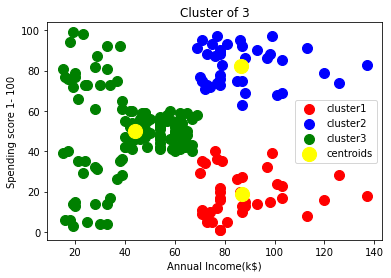

In [89]:
#identify for which values cluster is near by , X[y_mean==0,0] means position where y_means ==0,0 return that value from X

plt.scatter(X[y_means==0,0], X[y_means==0,1],s=100 , c='red', label='cluster1')

plt.scatter(X[y_means==1,0], X[y_means==1,1],s=100 , c='blue', label='cluster2')


plt.scatter(X[y_means==2,0], X[y_means==2,1],s=100 , c='green', label='cluster3')

#highlight centroids in scatter plot
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='yellow' , label= 'centroids')

plt.title('Cluster of 3')

plt.xlabel('Annual Income(k$)')

plt.ylabel('Spending score 1- 100')

plt.legend()

plt.show()

C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

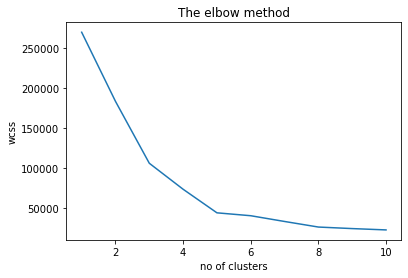

In [92]:
#choosing right cluster using model inertia

wcss=[ ]

for i in range(1,11):
    model =KMeans(n_clusters=i, init='k-means++', random_state= 42)
    model.fit(X)
    wcss.append(model.inertia_)


plt.plot(range(1,11),wcss)

plt.title('The elbow method')

plt.xlabel("no of clusters")

plt.ylabel('wcss')

plt.show()

C:\Users\sudhi\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


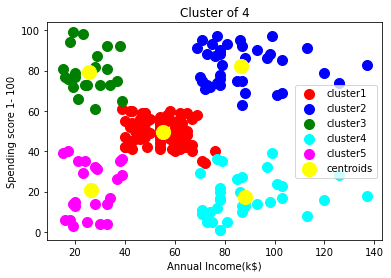

In [95]:
#create model with 5 , as graph above show cluster 5 show lowest wscc value

model =KMeans(n_clusters=5 , init='k-means++' , random_state= 42)

y_means =model.fit_predict(df.iloc[:,[3,4]].values)


#identify for which values cluster is near by , X[y_mean==0,0] means position where y_means ==0,0 return that value from X

plt.scatter(X[y_means==0,0], X[y_means==0,1],s=100 , c='red', label='cluster1')

plt.scatter(X[y_means==1,0], X[y_means==1,1],s=100 , c='blue', label='cluster2')


plt.scatter(X[y_means==2,0], X[y_means==2,1],s=100 , c='green', label='cluster3')

plt.scatter(X[y_means==3,0], X[y_means==3,1],s=100 , c='cyan', label='cluster4')

plt.scatter(X[y_means==4,0], X[y_means==4,1],s=100 , c='magenta', label='cluster5')


#highlight centroids in scatter plot
plt.scatter(model.cluster_centers_[:,0],model.cluster_centers_[:,1],s=200,c='yellow' , label= 'centroids')

plt.title('Cluster of 4')

plt.xlabel('Annual Income(k$)')

plt.ylabel('Spending score 1- 100')

plt.legend()

plt.show()

KeyError: 4